salePrice is my target variable and want to predict it.
The data have 1460 rows and 81 columns.
Dataset contains numerical , categorical and ordinal features.
Data have misiing values,9pool,garage,basement features have 
the maximum missing values. 

In [927]:
import os

In [928]:
os.getcwd()

'c:\\Users\\HP\\ml-project\\house-price-prediction\\notebooks'

In [929]:
import numpy as np
import pandas as pd
data = pd.read_csv('../data/raw/train.csv')
print("rows,columns",data.shape)
print(data.columns)

rows,columns (1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       '

Identifying the featurestype in dataset.

In [930]:
#for col,dtypes in data.dtypes.items():
 #   print(col,'-',dtypes)
#pd.set_option('display.max_rows',None)
data.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


In [931]:
pd.set_option('display.max_columns',None)
data.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,588,1452.000000,1460,1460,1460,1423,1423,1422,1423,1460.000000,1422,1460.000000,1460.000000,1460.000000,1460,1460,1460,1459,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460.000000,1460,1460.000000,770,1379,1379.000000,1379,1460.000000,1460.000000,1379,1379,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,5,3,25,9,8,5,8,NaN,NaN,NaN,NaN,6,8,15,16,3,NaN,4,5,6,4,4,4,6,NaN,6,NaN,NaN,NaN,6,5,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,NaN,5,6,NaN,3,NaN,NaN,5,5,3,NaN,NaN,NaN,NaN,NaN,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,BrkFace,NaN,TA,TA,PConc,TA,TA,No,Unf,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,Gd,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,NaN,NaN,NaN,NaN,1141,1434,515,504,445,NaN,906,1282,647,649,1311,953,430,NaN,1256,NaN,NaN,NaN,1428,741,1365,1334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735,NaN,1360,NaN,380,870,NaN,605,NaN,NaN,1311,1326,1340,NaN,NaN,NaN,NaN,NaN,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.099315,5.575342,1971.267808,1984.865753,NaN,NaN,NaN,NaN,NaN,103.685262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,443.639726,NaN,46.549315,567.240411,1057.429452,NaN,NaN,NaN,NaN,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,NaN,6.517808,NaN,0.613014,NaN,NaN,1978.506164,NaN,1.767123,472.980137,NaN,NaN,NaN,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.382997,1.112799,30.202904,20.645407,NaN,NaN,NaN,NaN,NaN,181.066207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456.098091,NaN,161.319273,441.866955,438.705324,NaN,NaN,NaN,NaN,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,NaN,1.625393,NaN,0.644666,NaN,NaN,24.689725,NaN,0.747315,213.804841,NaN,NaN,NaN,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1872.000000,1950.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,NaN,0.000000,NaN,NaN,1900.000000,N

Identifying null values in dataset.

In [932]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Identifying columns which have null(missing) values.

In [933]:
pd.set_option('display.max_rows',None)
missing = data.columns[data.isnull().any()]
print(missing)


Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')


In [934]:
#pd.set_option('display.max_rows',None) 
for col in missing:
    
    print(data[col].isnull().value_counts())
    print('\n')


LotFrontage
False    1201
True      259
Name: count, dtype: int64


Alley
True     1369
False      91
Name: count, dtype: int64


MasVnrType
True     872
False    588
Name: count, dtype: int64


MasVnrArea
False    1452
True        8
Name: count, dtype: int64


BsmtQual
False    1423
True       37
Name: count, dtype: int64


BsmtCond
False    1423
True       37
Name: count, dtype: int64


BsmtExposure
False    1422
True       38
Name: count, dtype: int64


BsmtFinType1
False    1423
True       37
Name: count, dtype: int64


BsmtFinType2
False    1422
True       38
Name: count, dtype: int64


Electrical
False    1459
True        1
Name: count, dtype: int64


FireplaceQu
False    770
True     690
Name: count, dtype: int64


GarageType
False    1379
True       81
Name: count, dtype: int64


GarageYrBlt
False    1379
True       81
Name: count, dtype: int64


GarageFinish
False    1379
True       81
Name: count, dtype: int64


GarageQual
False    1379
True       81
Name: count, dtype: int64

In [935]:
data['BsmtQual'].unique()


array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In this step we identyfies the outliers in different features

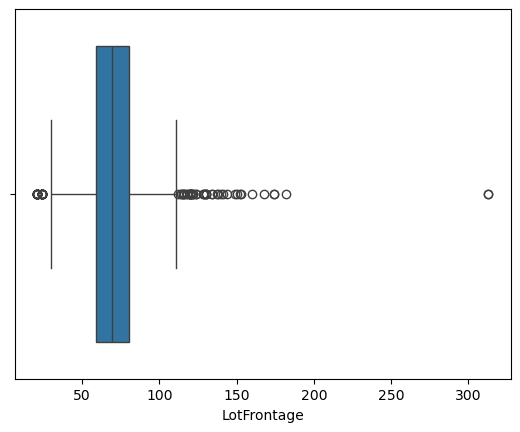

In [936]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=data['LotFrontage'])
plt.show()


Here we found multiple features with null(missing) values , all features are differentiated with their types.

| Feature Name | Data Type   | Category Type    | Missing Value Type |
| ------------ | ----------- | ---------------- | ------------------ |
| BsmtQual     | Categorical | Ordinal          | Structural         |
| BsmtCond     | Categorical | Ordinal          | Structural         |
| BsmtExposure | Categorical | Ordinal          | Structural         |
| BsmtFinType1 | Categorical | Ordinal          | Structural         |
| BsmtFinType2 | Categorical | Ordinal          | Structural         |
| FireplaceQu  | Categorical | Ordinal          | Structural         |
| GarageQual   | Categorical | Ordinal          | Structural         |
| GarageCond   | Categorical | Ordinal          | Structural         |
| PoolQC       | Categorical | Ordinal          | Structural         |
| Fence        | Categorical | Ordinal          | Structural         |
| GarageType   | Categorical | Nominal          | Structural         |
| GarageFinish | Categorical | Nominal          | Structural         |
| MiscFeature  | Categorical | Nominal          | Structural         |
| Alley        | Categorical | Nominal          | Structural         |
| MasVnrType   | Categorical | Nominal          | Structural         |
| MasVnrArea   | Numerical   | With Outliers    | Structural         |
| GarageYrBlt  | Numerical   | Without Outliers | Structural         |
| Electrical   | Categorical | Nominal          | **Accidental**     |
| LotFrontage  | Numerical   | With Outliers    | **Accidental**     |

For structural missing  value we replace it with suitable values. For accidental missing values we use (Mode for categrocial features) and (Midean for numerical feature).

First replacing structural missing values.


we replace all  basement type features('BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2') with 'Nobasement'

In [937]:
#find which are nullvalues NA or Nan 
print(data['BsmtQual'].isna().sum())
print((data['BsmtQual'] == 'NA').sum())

37
0


In [938]:
#Here we got 37 for Nan or o for NA . sor we are converting NA to np.nan
data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']] = data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']].replace('NA',np.nan)
from sklearn.impute import SimpleImputer
imputer_sb = SimpleImputer(missing_values =np.nan,strategy ='constant',fill_value='NoBasement' )
data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']] = imputer_sb.fit_transform(data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']])


In [939]:
#data.info()


Now for all garage type features we replace :
GarageQual,GarageCond,GarageType,GarageFinish with 'Nogarage'
or 
GarageYrBlt with 0

In [940]:
data[['GarageQual','GarageCond','GarageType','GarageFinish']] = data[['GarageQual','GarageCond','GarageType','GarageFinish']].replace('NA',np.nan)
imputer_sg = SimpleImputer(missing_values =np.nan,strategy ='constant',fill_value='NoGarage' )
data[['GarageQual','GarageCond','GarageType','GarageFinish']] = imputer_sg.fit_transform(data[['GarageQual','GarageCond','GarageType','GarageFinish']])

In [941]:
data['GarageYrBlt'] = data['GarageYrBlt'].replace('NA',np.nan)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)

Now in FireplaceQu replacing  with 'NoFireplace'

In [942]:
data['FireplaceQu'].isna().sum()

690

In [943]:
data['FireplaceQu'] = data['FireplaceQu'].replace('NA',np.nan)
data['FireplaceQu'] = data['FireplaceQu'].fillna('NoFireplace')

Now in PoolQC replacing with 'NoPoolArea'

In [944]:
data['PoolQC'].isna().sum()

1453

In [945]:
data['PoolQC'] = data['PoolQC'].replace('NA',np.nan)
data['PoolQC'] = data['PoolQC'].fillna('NoPoolArea')

Now in Fence replacing with 'NoFence'

In [946]:
data['Fence'].isna().sum()

1179

In [947]:
data['Fence'] = data['Fence'].replace('NA',np.nan)
data['Fence'] = data['Fence'].fillna('NoFence')

Now in MiscFeature replacing with 'None'

In [948]:
data['MiscFeature'].isna().sum()

1406

In [949]:
data['MiscFeature'] = data['MiscFeature'].replace('NA',np.nan)
data['MiscFeature'] = data['MiscFeature'].fillna('None')

Now in MasVnrType and MasVnrArea replacing with 'None' and 0

In [950]:
data['MasVnrType'].isna().sum()

872

In [951]:
data['MasVnrType'] = data['MasVnrType'].replace('NA',np.nan)
data['MasVnrType'] = data['MasVnrType'].fillna('None')

In [952]:
data['MasVnrArea'].isna().sum()

8

In [953]:
data['MasVnrArea'] = data['MasVnrArea'].replace('NA',np.nan)
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)

Now in Alley replacing with 'NoAlley'

In [954]:
data['Alley'].isna().sum()

1369

In [955]:
data['Alley'] = data['Alley'].replace('NA',np.nan)
data['Alley'] = data['Alley'].fillna('NoAlley')

Now handling accidental missing values

In Electrical replacing with most frequant value

In [956]:
data['Electrical'].isna().sum()

1

In [957]:
#finding most frequant value in Electrical 
data['Electrical'].value_counts().idxmax()

'SBrkr'

In [958]:
#So, replacing with 'SBrkr'
data['Electrical'] = data['Electrical'].replace('NA',np.nan)
data['Electrical'] = data['Electrical'].fillna('SBrkr')

In LotFrontage using Midean because of outliers

In [959]:
data['LotFrontage'].isna().sum()

259

In [960]:
data['LotFrontage'] = data['LotFrontage'].replace('NA',np.nan)
data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())

In [961]:
data.info()
data.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPoolArea,NoFence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPoolArea,NoFence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPoolArea,NoFence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPoolArea,NoFence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPoolArea,NoFence,None,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NoFireplace,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NoPoolArea,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NoPoolArea,NoFence,None,0,8,2007,WD,Normal,307000
7,8,60,RL,69.0,10382,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NoPoolArea,NoFence,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NoPoolArea,NoFence,None,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NoAlley,Reg

In [962]:
data.to_csv('cleaned_data.csv',index=False)